#  Neural Sentiment Classifier
### NLP Course Project —

**Architecture:** Word2Vec (300-d) → Feed-Forward NN → Sigmoid → P(Positive)

---

##  Cell 1 — Install Dependencies

In [1]:
!pip install -q gensim scikit-learn
print(' All packages ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.2 MB/s eta 0:00:00
 All packages ready!


##  Cell 2 — Imports

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import gensim.downloader as api
import re
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'  Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

  Device: cuda
   GPU: Tesla T4


##  Cell 3 — Spec A Part 1: Preprocessing Pipeline

In [3]:
def preprocess_text(text: str) -> list:
    """Clean and tokenize raw text input."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    return tokens

# Quick test
sample = "This movie was GREAT! Loved every minute of it :)"
print('Input  :', sample)
print('Tokens :', preprocess_text(sample))

Input  : This movie was GREAT! Loved every minute of it :)
Tokens : ['this', 'movie', 'was', 'great', 'loved', 'every', 'minute', 'of', 'it']


##  Cell 4 — Spec A Part 2: Load Pre-trained Word2Vec
 First download is ~1.6 GB — takes 2–5 minutes on Colab. Subsequent runs use cache.

In [4]:
print('Loading Word2Vec (Google News 300-d)...')
w2v = api.load('word2vec-google-news-300')
EMBEDDING_DIM = 300
print(f' Word2Vec loaded | Vocabulary: {len(w2v):,} words | Embedding dim: {EMBEDDING_DIM}')


def text_to_vector(tokens: list, model, dim: int = 300) -> np.ndarray:
    """
    Convert token list → fixed-size sentence vector (dim=300).
    Method: element-wise mean of all known word vectors.
    Unknown words are skipped; returns zero vector if no words found.
    """
    vecs = [model[t] for t in tokens if t in model]
    if vecs:
        return np.mean(vecs, axis=0).astype(np.float32)
    return np.zeros(dim, dtype=np.float32)


# Demo
demo_tokens = preprocess_text('The movie was absolutely fantastic')
demo_vec = text_to_vector(demo_tokens, w2v)
print(f'\nDemo sentence vector shape: {demo_vec.shape}')  # (300,)

Loading Word2Vec (Google News 300-d)...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
 Word2Vec loaded | Vocabulary: 3,000,000 words | Embedding dim: 300

Demo sentence vector shape: (300,)


##  Cell 5 — Dataset
> Using a built-in demo dataset. Replace `build_sample_dataset()` with IMDB/SST-2 for real training.

In [5]:
def build_sample_dataset():
    """50-sample demo dataset (25 pos / 25 neg). Replace for real experiments."""
    positive = [
        'This movie was absolutely wonderful and I loved every minute of it',
        'An outstanding film with brilliant performances and a great story',
        'I really enjoyed this product it works perfectly and exceeds expectations',
        'Fantastic experience the service was excellent and very professional',
        'Best purchase I have ever made highly recommend to everyone',
        'The food was delicious and the atmosphere was perfect and cozy',
        'Amazing book could not put it down a masterpiece of storytelling',
        'Incredible performance by the entire cast truly moving and inspiring',
        'Loved it so much will definitely come back again and again',
        'Great quality for the price very happy with this wonderful product',
        'Superb acting and direction made this a truly memorable experience',
        'I was blown away by the quality and attention to detail',
        'Absolutely brilliant could not have asked for anything better',
        'The storyline was captivating and kept me engaged throughout',
        'Outstanding customer service and fast shipping highly recommend',
        'This exceeded all my expectations a truly remarkable product',
        'Beautiful design and excellent build quality very impressed',
        'One of the best experiences I have ever had truly amazing',
        'The characters were well developed and the plot was engaging',
        'Perfect in every way I could not be happier with this purchase',
        'Wonderful atmosphere great food and amazing staff will return',
        'This is exactly what I needed and it works perfectly every time',
        'The quality is exceptional and the price is very reasonable',
        'Highly entertaining and thought provoking a must watch for everyone',
        'Incredible value for money I am extremely satisfied with everything',
    ]
    negative = [
        'This movie was terrible and a complete waste of my time',
        'Awful experience the product broke after just one day of use',
        'Very disappointed with the quality it was nothing like described',
        'Worst customer service I have ever encountered completely unhelpful',
        'Do not buy this it is a total scam and garbage quality',
        'The food was cold and tasteless I will never go back there',
        'Boring and predictable story with flat characters and poor acting',
        'Terrible performance the machine makes loud noise and does not work',
        'Hated it from start to finish a complete disappointment and failure',
        'Poor quality broke immediately and the company refused to refund',
        'Absolutely dreadful experience would not recommend to anyone at all',
        'The worst product I have ever bought complete waste of money',
        'Incredibly frustrating the instructions make no sense and it never works',
        'Disgusting food and rude staff I will never visit again',
        'The plot was confusing the acting was terrible an awful film',
        'Complete garbage stopped working after two days total disappointment',
        'I regret buying this it is poorly made and feels very cheap',
        'The service was appalling and the wait time was unacceptable',
        'Dreadful quality control this product failed on the very first use',
        'Misleading description the actual product is nothing like the photos',
        'Overpriced and underwhelming I expected so much more from this',
        'The delivery was late and the item arrived damaged beyond use',
        'Pointless and dull could not finish watching it was so boring',
        'Terrible experience from start to finish would give zero stars',
        'Extremely poor performance and the battery life is absolutely dreadful',
    ]
    return positive + negative, [1]*len(positive) + [0]*len(negative)


class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


texts, labels = build_sample_dataset()
print(f'Dataset: {len(texts)} samples  |  Positive: {sum(labels)}  |  Negative: {len(labels)-sum(labels)}')

print('Vectorizing sentences...')
vectors = np.array([text_to_vector(preprocess_text(t), w2v) for t in texts])
labels  = np.array(labels, dtype=np.float32)
print(f'Vector matrix shape: {vectors.shape}  (samples × embedding_dim)')

X_train, X_test, y_train, y_test = train_test_split(
    vectors, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

train_loader = DataLoader(SentimentDataset(X_train, y_train), batch_size=8, shuffle=True)
test_loader  = DataLoader(SentimentDataset(X_test,  y_test),  batch_size=8)

Dataset: 50 samples  |  Positive: 25  |  Negative: 25
Vectorizing sentences...
Vector matrix shape: (50, 300)  (samples × embedding_dim)
Train: 40  |  Test: 10


##  Cell 6 — Spec A Part 3: Feed-Forward Neural Network

In [6]:
class SentimentFFNN(nn.Module):
    """
    Feed-Forward Neural Network — Binary Sentiment Classifier

    Input  layer : 300 neurons  (matches Word2Vec embedding dim)
    Hidden layer : 128 neurons + ReLU  (non-linear activation)
    Hidden layer :  64 neurons + ReLU
    Output layer :   1 neuron  + Sigmoid  →  output in [0, 1]
                     0 = Negative,  1 = Positive
    """
    def __init__(self, input_dim=300):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()          # constrains output to [0, 1]
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


model = SentimentFFNN(input_dim=EMBEDDING_DIM).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {total_params:,}')

SentimentFFNN(
  (net): Sequential(
    (0): Linear(in_features=300, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total trainable parameters: 46,849


##  Cell 7 — Spec A Part 4: Loss, Optimizer & Training

In [7]:
# Binary Cross-Entropy — appropriate loss for binary classification
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            probs = model(X_b.to(device)).cpu().numpy()
            preds.extend((probs >= 0.5).astype(int))
            labels.extend(y_b.numpy().astype(int))
    return accuracy_score(labels, preds), preds, labels


EPOCHS = 50
print(f'Training for {EPOCHS} epochs on {device}...\n')
print(f'{"Epoch":>6}  {"Train Loss":>11}  {"Train Acc":>10}  {"Test Acc":>9}')
print('-' * 44)

train_losses, train_accs, test_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model, train_loader, optimizer, criterion)
    tr_acc, _, _ = evaluate(model, train_loader)
    te_acc, _, _ = evaluate(model, test_loader)

    train_losses.append(loss)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6}  {loss:>11.4f}  {tr_acc:>10.4f}  {te_acc:>9.4f}')

Training for 50 epochs on cuda...

 Epoch   Train Loss   Train Acc   Test Acc
--------------------------------------------
     1       0.6940      0.5000     0.5000
    10       0.4992      1.0000     0.9000
    20       0.0455      1.0000     0.8000
    30       0.0188      1.0000     0.8000
    40       0.0046      1.0000     0.8000
    50       0.0027      1.0000     0.8000


##  Cell 8 — Spec A Part 5: Quantitative Validation on Held-out Test Set

  FINAL TEST ACCURACY : 80.00%

              precision    recall  f1-score   support

    Negative       0.80      0.80      0.80         5
    Positive       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10



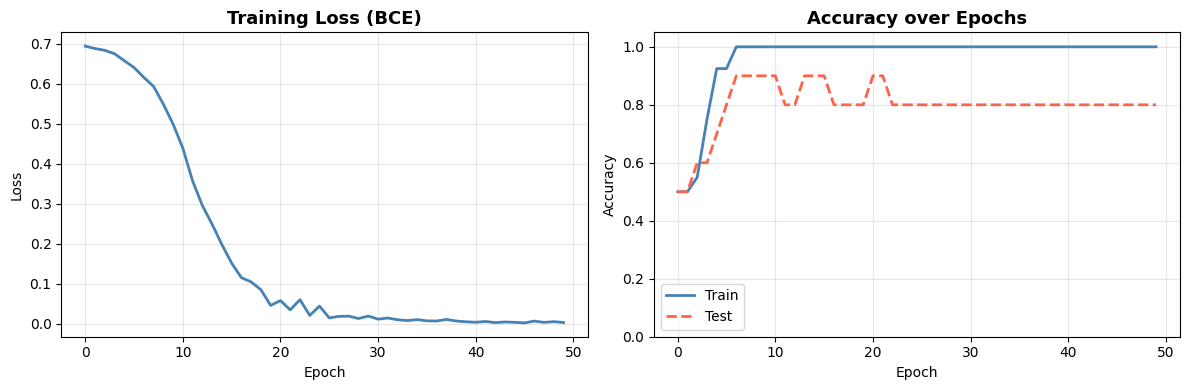

In [8]:
import matplotlib.pyplot as plt

final_acc, final_preds, final_labels = evaluate(model, test_loader)

print('=' * 50)
print(f'  FINAL TEST ACCURACY : {final_acc * 100:.2f}%')
print('=' * 50)
print()
print(classification_report(final_labels, final_preds, target_names=['Negative', 'Positive']))

# ── Plot training curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, color='steelblue', linewidth=2)
axes[0].set_title('Training Loss (BCE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(train_accs, label='Train', color='steelblue', linewidth=2)
axes[1].plot(test_accs,  label='Test',  color='tomato',    linewidth=2, linestyle='--')
axes[1].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

##  Cell 9 — Demo Inference

In [9]:
def predict(text: str) -> dict:
    """Predict sentiment for any raw text string."""
    model.eval()
    tokens = preprocess_text(text)
    vec    = text_to_vector(tokens, w2v)
    tensor = torch.tensor(vec, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = model(tensor).item()
    label = 'Positive ' if prob >= 0.5 else 'Negative '
    return {'text': text, 'probability': round(prob, 4), 'sentiment': label}


test_reviews = [
    'This product is absolutely amazing, I love it!',
    'Terrible quality, do not waste your money on this.',
    'The movie was okay, nothing special but not bad either.',
    'Incredible experience, highly recommend to everyone!',
    'Very disappointing, arrived broken and support was useless.',
]

print(f'{"Review":<55}  {"Score":>6}  Sentiment')
print('-' * 80)
for review in test_reviews:
    result = predict(review)
    short  = result['text'][:52] + '...' if len(result['text']) > 55 else result['text']
    print(f'{short:<55}  {result["probability"]:>6.4f}  {result["sentiment"]}')

Review                                                    Score  Sentiment
--------------------------------------------------------------------------------
This product is absolutely amazing, I love it!           0.9987  Positive 
Terrible quality, do not waste your money on this.       0.0005  Negative 
The movie was okay, nothing special but not bad either.  0.0108  Negative 
Incredible experience, highly recommend to everyone!     1.0000  Positive 
Very disappointing, arrived broken and support was u...  0.0000  Negative 


##  Cell 10 — Save Model

In [10]:
torch.save(model.state_dict(), 'sentiment_model.pth')
print(' Model saved to sentiment_model.pth')

# To reload later:
# model2 = SentimentFFNN(input_dim=300)
# model2.load_state_dict(torch.load('sentiment_model.pth'))
# model2.eval()

 Model saved to sentiment_model.pth
